## GetPoint reference
Obtain points to adapt and extract the required image

In [ ]:
import cv2
import os

img = cv2.imread("../dataset/empty_board/first_half.jpg")

def click_event(event, x, y, flags, param):
    points = []
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print("Clicked:", x, y)


cv2.imshow("image", img)
cv2.setMouseCallback("image", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()


### some functions def

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10,8))

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("on")
    plt.show()

def findImage(imageToFind, WholeImage):
    orb = cv2.ORB_create(nfeatures=5000)
    kp1, des1 = orb.detectAndCompute(imageToFind, None)
    kp2, des2 = orb.detectAndCompute(WholeImage, None)

    if des1 is None or des2 is None:
        return None

    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = matcher.match(des1, des2)

    matches_gms = cv2.xfeatures2d.matchGMS(
        imageToFind.shape[:2],
        WholeImage.shape[:2],
        kp1,
        kp2,
        matches,
        withRotation=False,
        withScale=True,
        thresholdFactor=6
    )


    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches_gms]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches_gms]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    mask = mask.ravel().astype(bool)
    inlier_matches = [m for m, keep in zip(matches_gms, mask) if keep]

    show_image(
        cv2.drawMatches(imageToFind, kp1, WholeImage, kp2, inlier_matches, None,
                        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS),
        "Inlier Matches"
    )

    h, w = WholeImage.shape[:2]
    #corners = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]]).reshape(-1, 1, 2)
    #projected = cv2.perspectiveTransform(corners, H)

    #vis = imageToFind.copy()
    #vis = cv2.polylines(vis, [np.int32(projected)], True, (0, 255, 0), 2)
    #show_image(vis, "Projected corners")

    return cv2.warpPerspective(WholeImage, H, (int(imageToFind.shape[1]), int(imageToFind.shape[0])))

def rotate_left(image,times=1):
    for _ in range(times):
        image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return image

# backgroundTargetImage → immagine di sfondo da trovare
# backgroundRequiredAreasection → area di sfondo necessaria per individuare il target
# completeImage → immagine completa in cui cercare il target
def findPart(RequiredMiddleAreaSections, completeImage):
    for area in RequiredMiddleAreaSections:
        completeImage = findImage(area, completeImage)

    return completeImage


### Get reference pictures

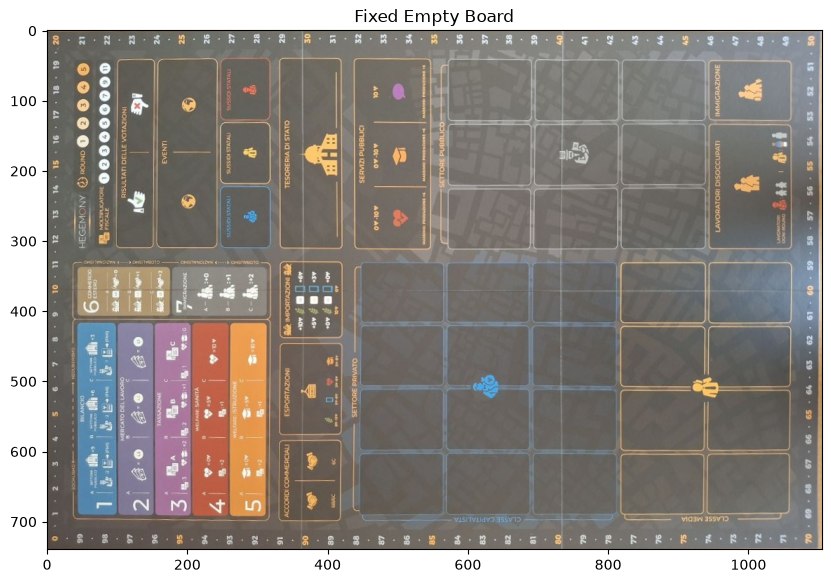

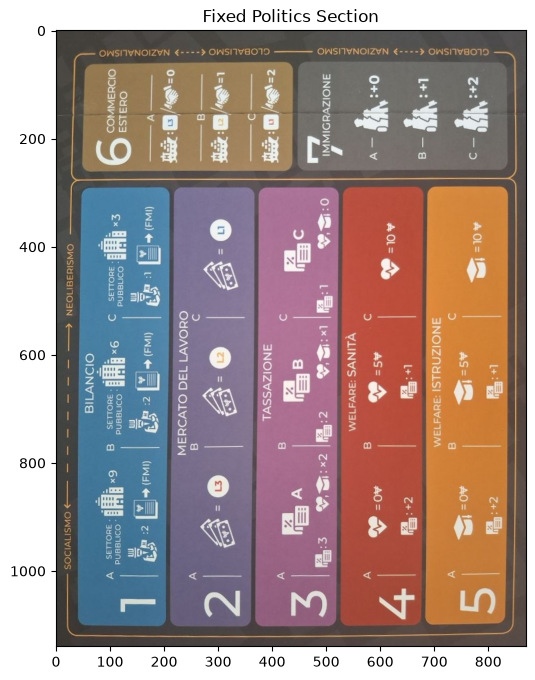

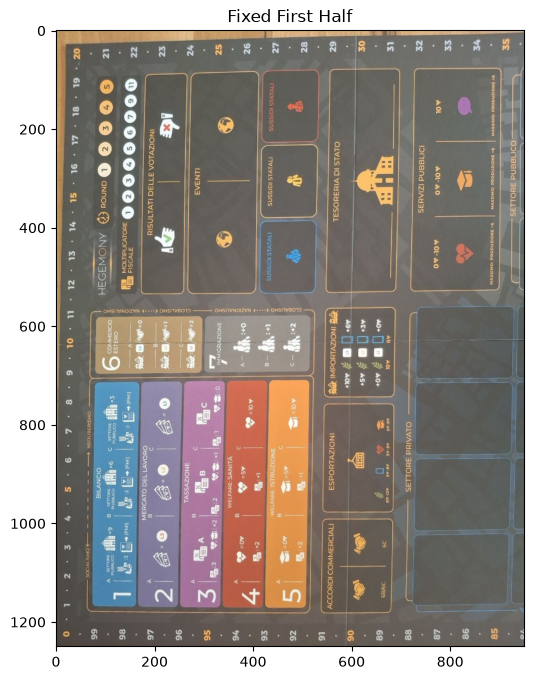

In [3]:


#board corners
board_src = np.float32([[91,16], [885, 19], [920, 1260], [50, 1260]])
BoardW, BoardH = 1105, 740
board_dst = np.float32([ [0, BoardH-1],[0, 0], [BoardW-1, 0], [BoardW-1, BoardH-1]])
rawemptyBoard = cv2.imread("../dataset/empty_board/complete.jpg")
boardmatrix = cv2.getPerspectiveTransform(board_src, board_dst)
fixed_emptyBoard = cv2.warpPerspective(rawemptyBoard, boardmatrix, (BoardW, BoardH))

politics_src = np.float32([[68, 64], [928, 94], [74, 1211], [938, 1186]])
PoliticW, PoliticH =  1140, 870
politics_dst = np.float32([ [0, PoliticH-1],[0, 0], [PoliticW-1, PoliticH-1], [PoliticW-1, 0]])
raw_empty_politics_section = cv2.imread("../dataset/empty_board/politics.jpg")
politics_matrix = cv2.getPerspectiveTransform(politics_src, politics_dst)
fixed_politics_section = cv2.warpPerspective(raw_empty_politics_section, politics_matrix, (PoliticW, PoliticH))
fixed_politics_section = rotate_left(fixed_politics_section)

firstHalf_src = np.float32([[959, 74], [4, 18], [2, 1252], [947, 1256]])
firstHalfW, firstHalfH = 950, 1250
firstHalf_dst = np.float32([ [0, firstHalfH-1],[firstHalfW-1, firstHalfH-1],[firstHalfW-1, 0], [0, 0]])
raw_empty_first_half = cv2.imread("../dataset/empty_board/first_half.jpg")
firstHalf_matrix = cv2.getPerspectiveTransform(firstHalf_src, firstHalf_dst)
fixed_first_half = cv2.warpPerspective(raw_empty_first_half, firstHalf_matrix, (firstHalfW, firstHalfH))

show_image(fixed_emptyBoard, "Fixed Empty Board")
show_image(fixed_politics_section, "Fixed Politics Section")
show_image(fixed_first_half, "Fixed First Half")









### Warp and Cut extra parts

In [4]:

def crop_image(image, percetageLeft, percetageRight, percetageTop, percetageBottom):
    height, width = image.shape[:2]
    left = int(width * percetageLeft)
    right = int(width * percetageRight)
    top = int(height * percetageTop)
    bottom = int(height * percetageBottom)

    cropped_image = image[top:height-bottom, left:width-right]
    return cropped_image

def crop_half2politics(image):
    return crop_image(image, 0.0, 0.30, 0.35, 0.0)

### FindHomography

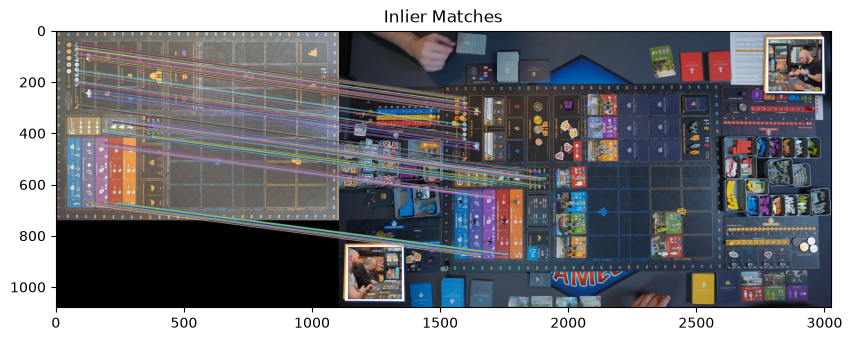

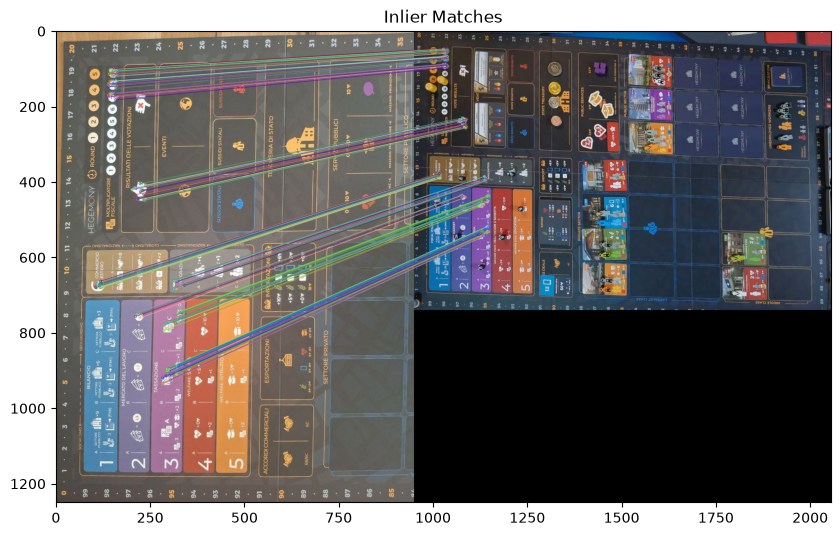

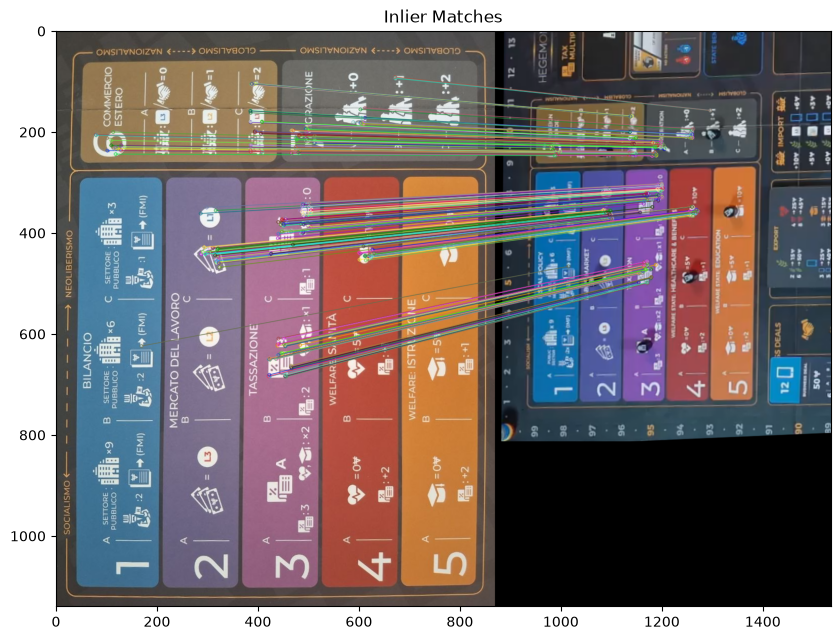

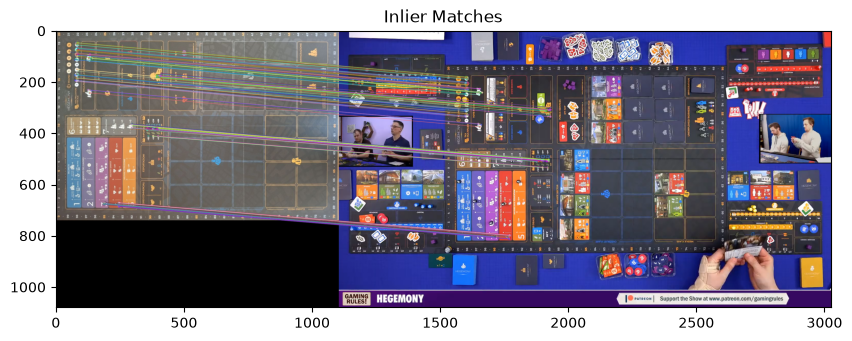

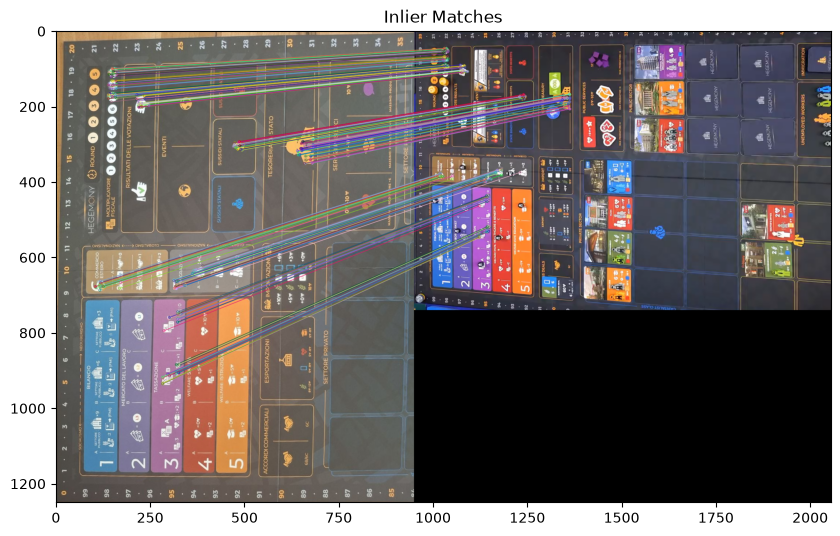

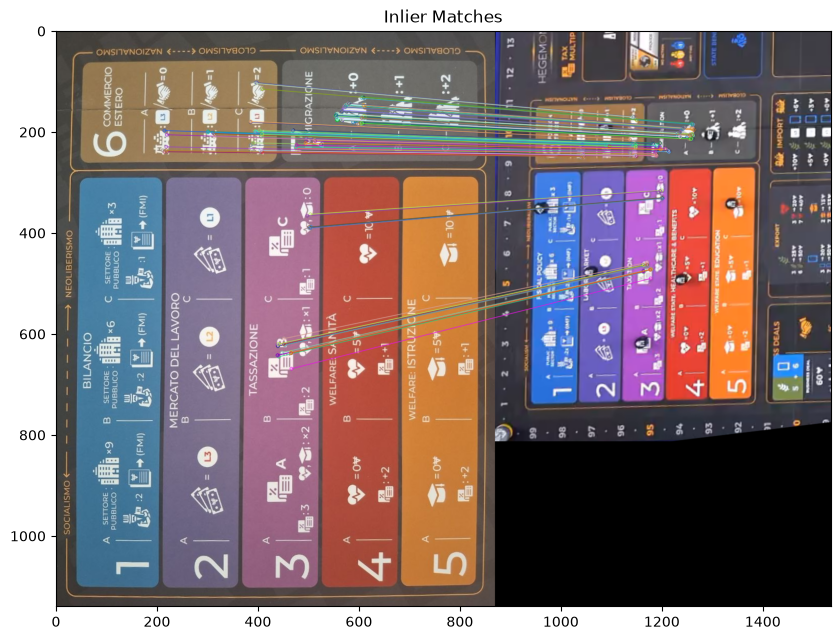

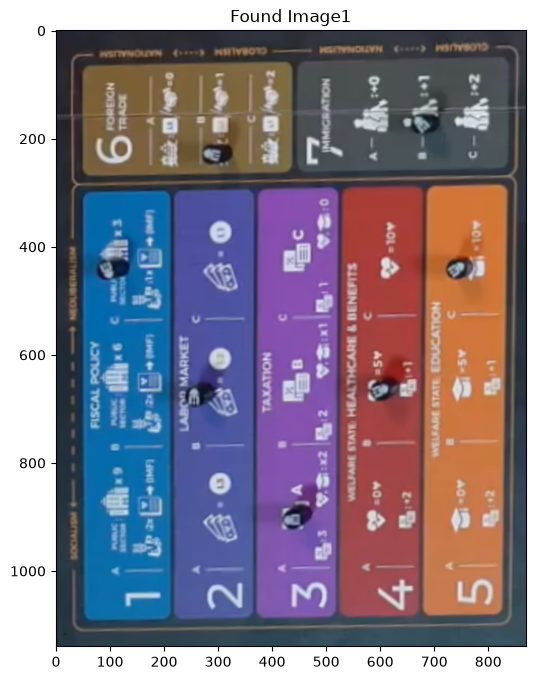

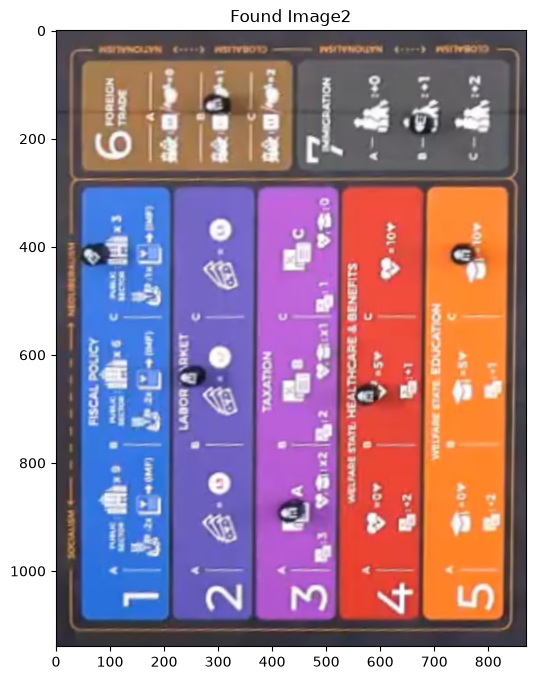

In [5]:






#image to find
secondImage = cv2.imread("../dataset/Game_1/005.png")
thirdImage = cv2.imread("../dataset/Game_2/008.png")


middleAreaSections = [fixed_emptyBoard, fixed_first_half]


politics1=findPart(middleAreaSections, secondImage)
politics1=crop_half2politics(politics1)
politics1=findPart([fixed_politics_section], politics1)

politics2=findPart(middleAreaSections, thirdImage)
politics2=crop_half2politics(politics2)
politics2=findPart([fixed_politics_section], politics2)

show_image(politics1, "Found Image1")
show_image(politics2, "Found Image2")




### GetSmallerSections

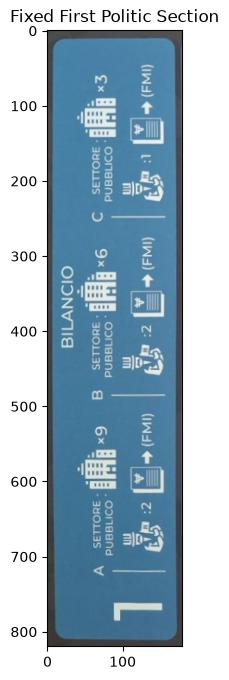

In [6]:
politics_src = np.float32([[40, 280], [220, 280], [30, 1110], [210, 1110]])
W, H  =  180, 820
politics_dst = np.float32([ [0, 0],[W-1, 0], [0, H-1], [W-1, H-1]])
politics_matrix = cv2.getPerspectiveTransform(politics_src, politics_dst)
fixedFirstPolitic = cv2.warpPerspective(fixed_politics_section, politics_matrix, (W, H))

show_image(rotate_left(fixedFirstPolitic,0), "Fixed First Politic Section")  


### backgroundSubtraction

Non funziona ancora

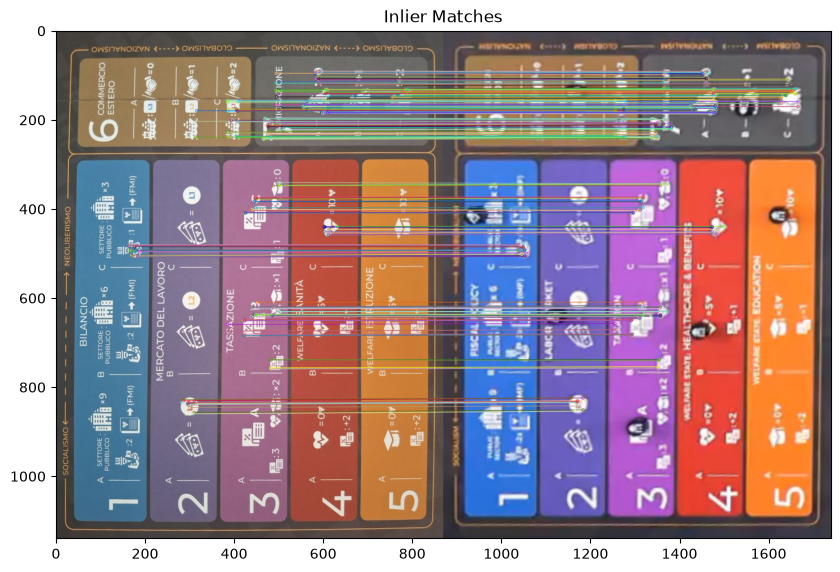

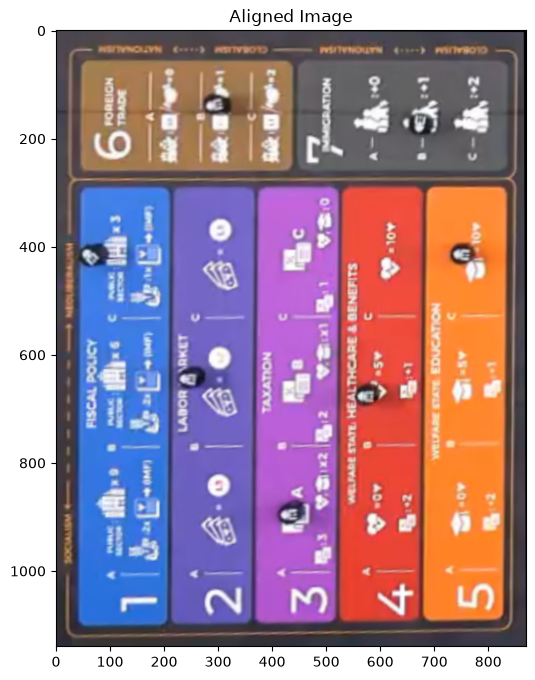

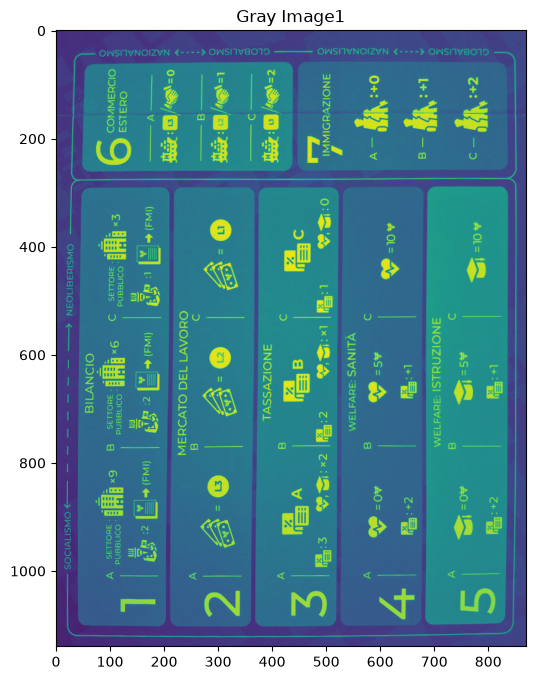

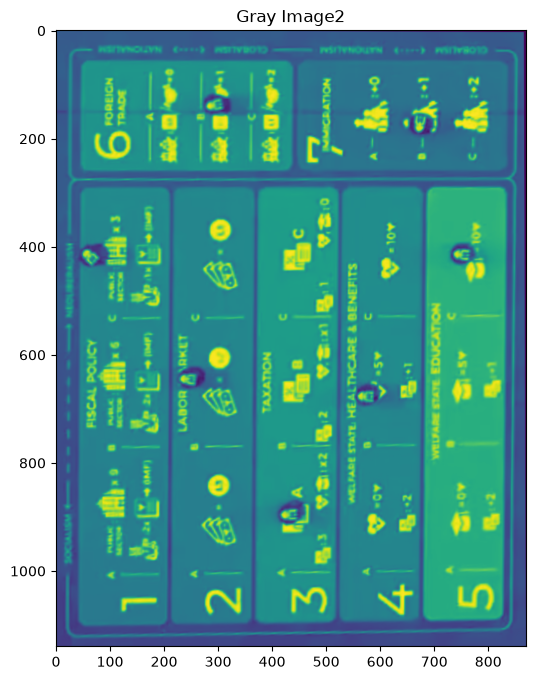

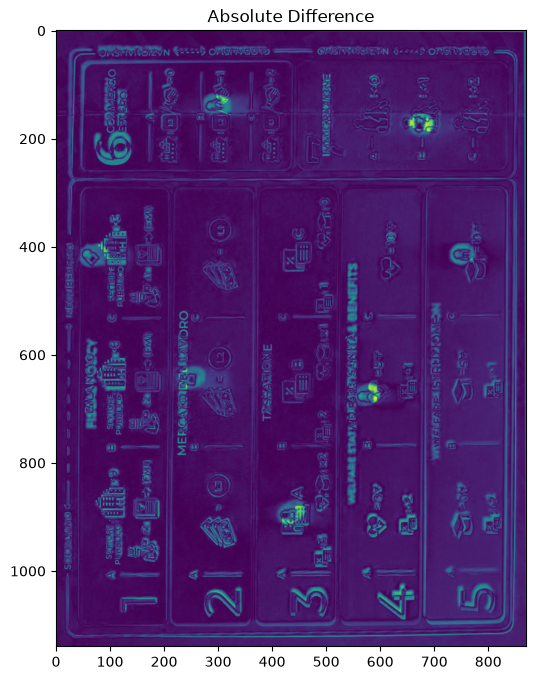

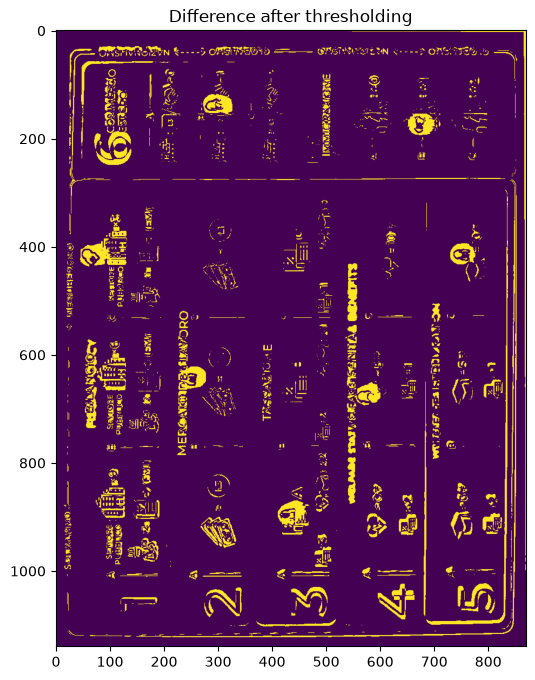

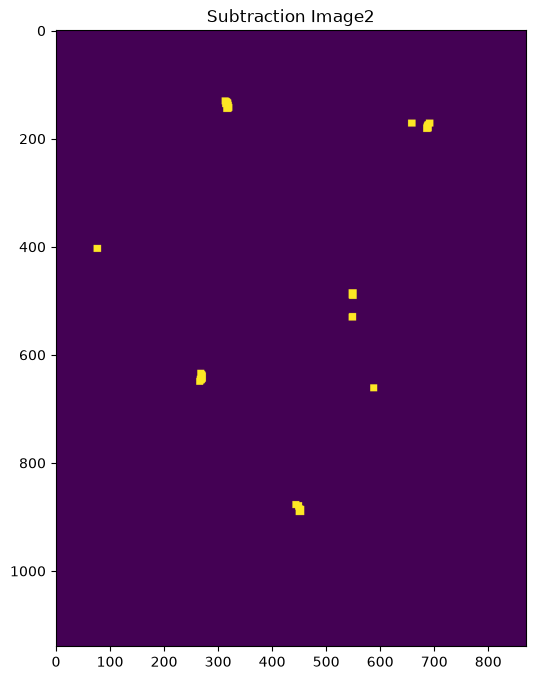

In [ ]:
def getSubtraction(img1,img2,threshold):
    if img1 is None or img2 is None:
        print("One of the images is None. Cannot perform subtraction.")
        return None
    if(img1.shape != img2.shape):
        print(f"Images have different shapes: {img1.shape} vs {img2.shape}. Resizing img2 to match img1.")
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    show_image(gray1, "Gray Image1")
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    show_image(gray2, "Gray Image2")
    diff = cv2.absdiff(gray1, gray2)
    show_image(diff, "Absolute Difference")
    _, thresh = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
    return thresh

def applyOpening(img,iterations=2):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    return cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel, iterations=iterations)

def applyClosing(img, iterations=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    return cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=iterations)

def elaborateDifference(backgroundImage, targetImage, threshold=50, iterations=3):
    allined=findImage(backgroundImage, targetImage)
    show_image(allined, "Aligned Image")
    difference=getSubtraction(backgroundImage, allined, threshold)
    show_image(difference, "Difference after thresholding")
    closed = applyClosing(difference, 0)
    opened = applyOpening(closed, iterations)
    return applyClosing(opened, 1)


show_image(elaborateDifference(fixed_politics_section, politics1), "Final Image")
#show_image(elaborateDifference(fixed_politics_section, politics2), "Subtraction Image2")

